# Evaluating outlier detection 

In [49]:
import pandas as pd
import cProfile
import pstats
import find_outliers.find_outliers as outliner_detection
import timeit
import datasets
import matplotlib.pyplot as plt

## Performance evaluation
We'll meassure the runtime of outliner detection module on different columns with various sizes and distict values

In [52]:
datasets = {'carprices':
                {'path':'../datasets/carprices/car_prices.csv',
                'columns':['make', 'model', 'trim']},
            'kickstarter':
                {'path':'../datasets/kickstarter/ks-projects-201801.csv',
                'columns': ['category', 'country']},
            # 'salaries': 
            #     {'path': '../datasets/salaries/ds_salaries.csv',
            #      'columns': ['job_title']}
            }

        
def profile_outliers(num_executions, sample_size):   
    results = {}
    for dataset_name, dataset_info in datasets.items():
        df = pd.read_csv(dataset_info['path'])
        # the seed used for the plot in the paper
        # df = df.sample(sample_size, random_state=5252)
        df = df.sample(sample_size)
        for column in dataset_info['columns']:
            print(f"Profiling outliers for column '{column}' in dataset '{dataset_name}'")
            total_execution_time = 0
            for _ in range(num_executions):
                start_time = timeit.default_timer()
                outliner_detection_result = outliner_detection.outliers(df, column)
                execution_time = timeit.default_timer() - start_time
                total_execution_time += execution_time
            average_execution_time = total_execution_time / num_executions
            unique_values = df[column].nunique()
            results[f"{column}"] = {"average_execution_time": average_execution_time, "unique_values": unique_values}
    return results


Profiling outliers for column 'make' in dataset 'carprices'
Profiling outliers for column 'model' in dataset 'carprices'
Profiling outliers for column 'trim' in dataset 'carprices'
Profiling outliers for column 'category' in dataset 'kickstarter'
Profiling outliers for column 'country' in dataset 'kickstarter'


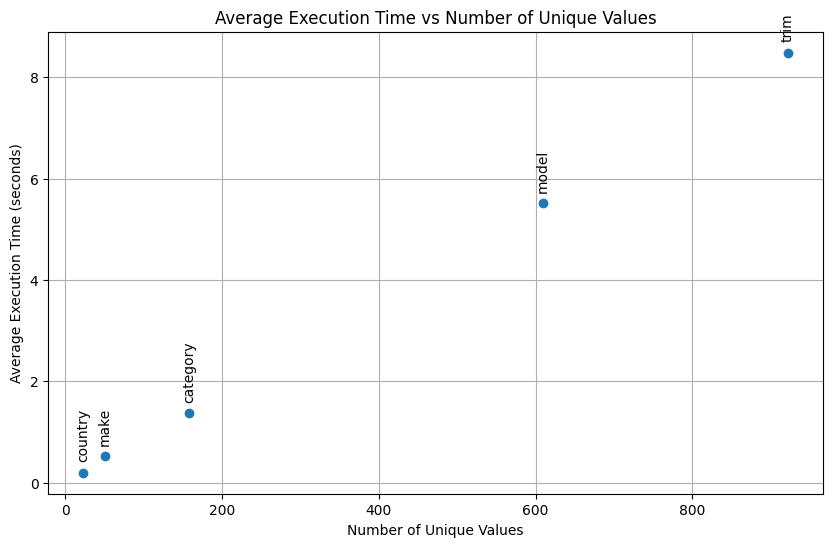

In [53]:
execution_results = profile_outliers(5, 20000)

# Extract data for plotting
x = [value['unique_values'] for value in execution_results.values()]
y = [value['average_execution_time'] for value in execution_results.values()]
labels = list(execution_results.keys())

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y)
for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center', rotation=90)  # Rotate text by 90 degrees
plt.xlabel('Number of Unique Values')
plt.ylabel('Average Execution Time (seconds)')
plt.title('Average Execution Time vs Number of Unique Values')
plt.grid(True)
plt.show()